# 线性回归

## 1 线性模型
- 给定 $n$ 维输入 $$x = [x_1, x_2, ..., x_n]^T$$
- 模型包含 $n$ 维权重和标量偏置 $$w = [w_1, w_2, ..., w_n]^T, b$$
- 模型输出为加权和 $$y = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b = w^T x + b$$

## 2 损失函数
假设真实值 $y$，预测值为 $\hat{y}$
- 平方误差损失函数 $$ l = (y - \hat{y})^2 $$
- 绝对误差损失函数 $$ l = |y - \hat{y}| $$

## 3 优化方法
小批量随机梯度下降（SGD）
- 随机采样 $b$ 个样本 $i_1, i_2, ..., i_b$
- 损失近似为 $$ L = \frac{1}{b} \sum_{i\in I_b} l_i $$
- 计算梯度 $$ \nabla_w L = \frac{1}{b} \sum_{i\in I_b} \nabla_w l_i $$


# 线性回归实现

In [6]:
from sympy.simplify.radsimp import numer_expand
%matplotlib inline
import random
import torch
import matplotlib.pyplot as plt

## 1 构造数据集
根据带噪声的线性模型生成数据集
$$ y = Xw + b + \epsilon $$
其中 $\epsilon$ 为服从均值为 0 的噪声。

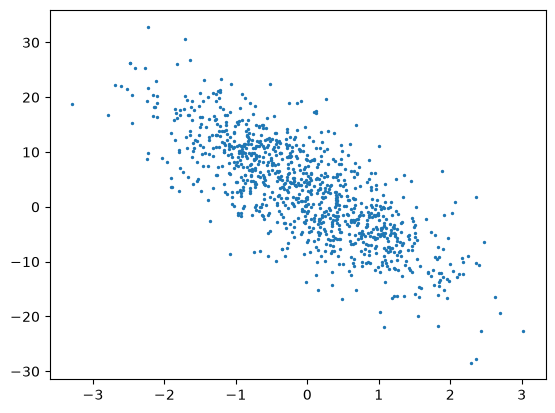

In [13]:
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    # 生成均值为 0，标准差为 1 的正态分布的随机数
    X = torch.normal(0, 1, (num_examples, len(w)))
    # 计算真实 y
    y = torch.matmul(X, w) + b
    # 添加噪声
    y += torch.normal(0, 0.01, y.shape)
    # y 需要被 reshape 成列向量
    return X, y.reshape((-1, 1))

# 构造数据
true_w = torch.tensor([6, -7], dtype=torch.float)
true_b = 3.1
features, labels = synthetic_data(true_w, true_b, 1000)

# 选择一个维度绘制投影散点图
plt.scatter(features[:, 1], labels[:, 0], 2)
plt.show()

## 2 读取数据
根据批量大小、特征矩阵和标签向量，生成一个小批量随机样本迭代器。

In [14]:
def data_iter(batch_size, features, labels):
    """生成一个小批量随机样本迭代器"""
    # 随机打乱样本的读取顺序
    num_examples = len(features)
    indices = list(range(num_examples)) # 生成索引列表
    random.shuffle(indices) # 随机打乱索引列表
    # 按批量大小切割小批量样本
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)]) # 取出当前批量的索引
        yield features[batch_indices], labels[batch_indices] # yield 返回一个迭代器

## 3 初始化模型
- 一个矩阵 $w_{2 \times 1}$，其中 $2$ 为输入维度，$1$ 为输出维度。一个偏置 $b$。
- 另外定义损失函数等

In [19]:
class Linear:
    """线性回归模型"""
    def __init__(self):
        self.w = torch.normal(mean=0, std=0.01, size=[2, 1], requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)
    def forward(self, X):
        """前向传播"""
        return torch.matmul(X, self.w) + self.b

def squared_loss(y_hat, y):
    """平方误差损失函数"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad(): # 不需要计算梯度，直接下降
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_() # 清空梯度

## 4 训练模型
训练模型的步骤
1. 读取数据
2. 计算损失
3. 反向传播计算梯度
4. 更新参数


epoch 1, loss 0.118830
epoch 2, loss 0.000385
epoch 3, loss 0.000050


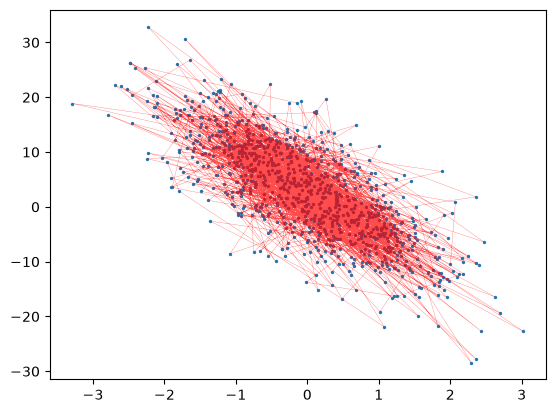

In [31]:
lr = 0.03 # 学习率
num_epochs = 3 # 训练轮数
batch_size = 10 # 批量大小
loss = squared_loss # 损失函数
model = Linear() # 初始化模型

# 进入训练轮次
for epoch in range(num_epochs):
    # 进入批次迭代
    for X, y in data_iter(batch_size, features, labels):
        l = loss(model.forward(X), y) # 计算损失
        l.sum().backward() # 反向传播计算梯度
        sgd([model.w, model.b], lr, batch_size) # 更新参数
    # 每轮训练结束，计算当前模型在整个数据集上的损失
    with torch.no_grad():
        train_l = loss(model.forward(features), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

plt.scatter(features[:, 1], labels[:, 0], 2)
plt.plot(features[:, 1], model.forward(features).detach().numpy(), 'r', linewidth=0.2, alpha=0.7)
plt.show()

# 线性回归简单实现
使用 PyTorch 的 nn 模块迅速实现

## 1 数据迭代器
使用 DataLoader 生成小批量数据迭代器

In [32]:
from torch.utils.data import DataLoader, TensorDataset
def load_array(data_arrays: tuple, batch_size, is_train=True):
    """构造一个 PyTorch 数据迭代器"""
    dataset = TensorDataset(*data_arrays) # 将特征和标签打包成数据集
    return DataLoader(dataset, batch_size, shuffle=is_train) # 返回数据迭代器

## 2 初始化模型
使用 nn.Sequential 定义模型，nn.Linear 定义线性层

In [53]:
from torch import nn
# 定义模型
model = nn.Sequential(nn.Linear(2, 1)) # 定义线性回归模型
model[0].weight.data.normal_(0, 0.01) # 初始化权重
model[0].bias.data.fill_(0) # 初始化偏置
# 定义损失函数和优化器
loss = nn.MSELoss()
trainer = torch.optim.SGD(model.parameters(), lr=0.03)

## 3 训练模型
步骤同上

In [54]:
num_epochs = 3
batch_size = 10
# 进入训练轮次
for epoch in range(num_epochs):
    # 进入批次迭代
    for X, y in load_array((features, labels), batch_size):
        l = loss(model(X), y) # 计算损失
        trainer.zero_grad() # 清空梯度
        l.backward() # 反向传播计算梯度
        trainer.step() # 更新参数
    with torch.no_grad():
        train_l = loss(model(features), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l):f}')

epoch 1, loss 0.000606
epoch 2, loss 0.000098
epoch 3, loss 0.000098
